# Crop Water Quantity Prediction - Regression Notebook

**Objective:** Build a supervised Machine Learning regression pipeline that predicts
the daily crop water requirement from crop, soil, climate, irrigation, and field
management variables.

The target used in this dataset is `Water_Need_mm_day`, which represents the
water depth required per day in millimeters. When field area is available,
this can be converted to a daily water volume:

`liters_per_day = predicted_mm_day * field_area_hectare * 10000`

This notebook follows the requested production-style pipeline:

1. Complete library imports
2. Data loading
3. Exploratory Data Analysis and visualization
4. Data preprocessing and feature engineering
5. Model building and training
6. Model evaluation
7. Model artifact saving for the Streamlit dashboard

## 1. Complete Library Imports

Keep imports in one place so the environment requirements are explicit.

In [25]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from crop_water_model_utils import (
    IQRClipper,
    add_engineered_features,
    make_one_hot_encoder,
    to_jsonable,
)

try:
    from xgboost import XGBRegressor

    XGBOOST_AVAILABLE = True
except ImportError:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COL = "Water_Need_mm_day"
MAX_REASONABLE_TEST_R2 = 0.95

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"

print("XGBoost available:", XGBOOST_AVAILABLE)

XGBoost available: True


## 2. Data Loading

The first path is the requested placeholder (`crop_water_data.csv`). The second
path points to the dataset location used in this project workspace.

In [9]:
candidate_paths = [
    Path("crop_water_data.csv"),
    Path("../data sets/crop_water_prediction_dataset_with_source.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), candidate_paths[0])

display(df.head())

,CropType,SoilType,CropGrowthStage,Season,SoilpH,SoilMoisture,OrganicCarbon,ElectricalConductivity,TemperatureC,Humidity,...,Nitrogenkgha,Phosphoruskgha,Potassiumkgha,IrrigationType,MulchingUsed,FieldAreahectare,PreviousIrrigationmm,WaterNeedmmday,IrrigationNeedLabel,Source
0,Cotton,Loamy,Vegetative,Rabi,7.270000,42.790000,1.350000,3.300000,32.310000,59.360000,...,47.293625,70.4604,45.562527,Drip,Yes,11.720000,40.07,7.69,Low,irrigation_prediction
1,Tomato,Loamy,Flowering,Greenhouse,6.600000,55.189228,2.619277,1.450055,24.100000,71.700000,...,162.000000,95.0000,170.000000,Drip,No,0.123835,6.12,2.91,Low,greenhouse_yields
2,Wheat,Peaty,Harvest,Rabi,4.508464,64.130000,2.740000,0.320000,29.802481,86.980061,...,125.800000,85.7000,51.300000,Canal,Yes,10.250000,16.72,5.00,Medium,sensor_crop
3,Maize,Sandy,Flowering,Kharif,6.551299,15.890000,0.870000,2.450000,26.586328,98.716975,...,63.600000,19.3000,80.900000,Sprinkler,No,12.470000,36.47,21.43,High,sensor_crop
4,Tomato,Loamy,Harvest,Greenhouse,6.500000,66.718071,2.805141,1.843712,25.400000,74.600000,...,203.000000,88.0000,150.000000,Drip,No,0.103693,8.01,3.81,Low,greenhouse_yields


In [4]:
if TARGET_COL not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' was not found. Available columns: {df.columns.tolist()}"
    )

display(
    pd.DataFrame(
        {
            "column": df.columns,
            "dtype": [str(dtype) for dtype in df.dtypes],
            "non_null_count": df.notna().sum().values,
            "missing_count": df.isna().sum().values,
            "unique_values": df.nunique(dropna=True).values,
        }
    )
)

,column,dtype,non_null_count,missing_count,unique_values
0,Crop_Type,object,38854,0,10
1,Soil_Type,object,38854,0,6
2,Crop_Growth_Stage,object,38854,0,4
3,Season,object,38854,0,4
4,Soil_pH,float64,38854,0,20341
5,Soil_Moisture_%,float64,38854,0,15472
6,Organic_Carbon_%,float64,38854,0,9175
7,Electrical_Conductivity,float64,38854,0,9245
8,Temperature_C,float64,38854,0,22906
9,Humidity_%,float64,38854,0,25447


## 3. Exploratory Data Analysis and Visualization

This section examines data quality, distributions, feature relationships, target
behavior, and potential outliers before any modeling decisions are made.

In [5]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38854 entries, 0 to 38853
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Crop_Type                38854 non-null  object 
 1   Soil_Type                38854 non-null  object 
 2   Crop_Growth_Stage        38854 non-null  object 
 3   Season                   38854 non-null  object 
 4   Soil_pH                  38854 non-null  float64
 5   Soil_Moisture_%          38854 non-null  float64
 6   Organic_Carbon_%         38854 non-null  float64
 7   Electrical_Conductivity  38854 non-null  float64
 8   Temperature_C            38854 non-null  float64
 9   Humidity_%               38854 non-null  float64
 10  Rainfall_mm              38854 non-null  float64
 11  Sunlight_Hours           38854 non-null  float64
 12  Wind_Speed_kmh           38854 non-null  float64
 13  Nitrogen_kg_ha           38854 non-null  float64
 14  P

In [6]:
df.columns = df.columns.str.replace(r'[^a-zA-Z0-9]', '', regex=True)
print(df.columns.tolist())

['CropType', 'SoilType', 'CropGrowthStage', 'Season', 'SoilpH', 'SoilMoisture', 'OrganicCarbon', 'ElectricalConductivity', 'TemperatureC', 'Humidity', 'Rainfallmm', 'SunlightHours', 'WindSpeedkmh', 'Nitrogenkgha', 'Phosphoruskgha', 'Potassiumkgha', 'IrrigationType', 'MulchingUsed', 'FieldAreahectare', 'PreviousIrrigationmm', 'WaterNeedmmday', 'IrrigationNeedLabel', 'Source']


In [8]:
numeric_cols_eda = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols_eda = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric columns ({len(numeric_cols_eda)}): {numeric_cols_eda}")
print(f"Categorical columns ({len(categorical_cols_eda)}): {categorical_cols_eda}")

display(df[numeric_cols_eda].describe().T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CropType,38854,10,Tomato,6827,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SoilType,38854,6,Loamy,14549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CropGrowthStage,38854,4,Flowering,11380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,38854,4,Kharif,13266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SoilpH,38854.0,NaN,NaN,NaN,6.49634,0.995243,4.500082,5.750497,6.5,7.237134,8.499914
SoilMoisture,38854.0,NaN,NaN,NaN,45.130048,19.449054,8.0,29.2925,45.85,61.12,79.994734
OrganicCarbon,38854.0,NaN,NaN,NaN,1.78936,0.925257,0.3,0.99,1.68,2.595996,3.5
ElectricalConductivity,38854.0,NaN,NaN,NaN,1.898352,0.996055,0.1,1.10337,1.84,2.63,4.0
TemperatureC,38854.0,NaN,NaN,NaN,26.395547,8.730399,10.00376,19.859633,25.4,33.0,44.997407
Humidity,38854.0,NaN,NaN,NaN,65.960371,18.970757,25.0,50.92146,68.650436,80.949491,100.0


In [10]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: x["missing_count"] / len(df) * 100)
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

if missing_summary.empty:
    print("No missing values were detected.")
else:
    display(missing_summary)

No missing values were detected.


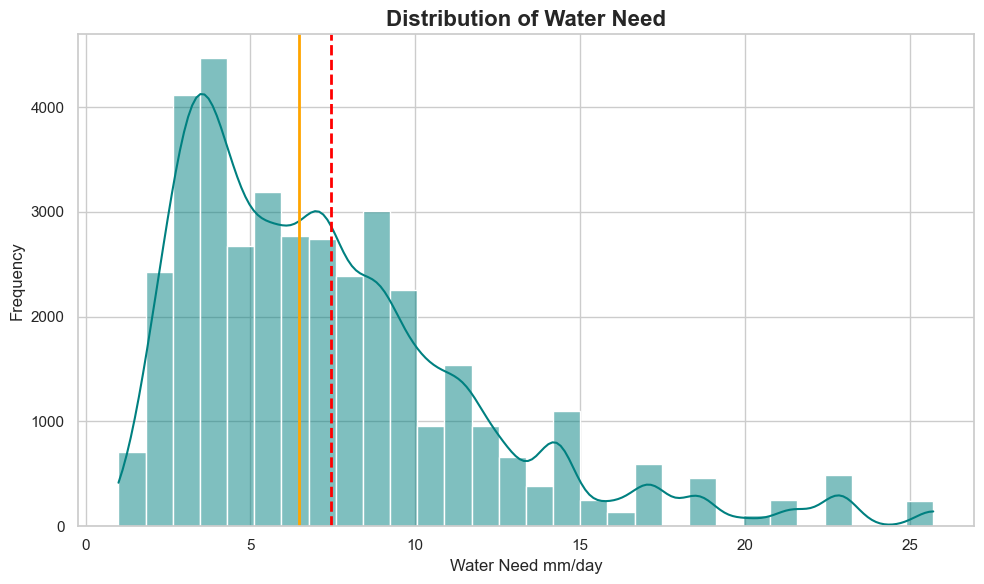

In [13]:
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 6))
sns.histplot(df['WaterNeedmmday'], bins=30, kde=True, color='teal')
plt.axvline(df['WaterNeedmmday'].mean(), color='red', linestyle='--', linewidth=2)
plt.axvline(df['WaterNeedmmday'].median(), color='orange', linestyle='-', linewidth=2)
plt.title('Distribution of Water Need', fontsize=16, fontweight='bold')
plt.xlabel('Water Need mm/day', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

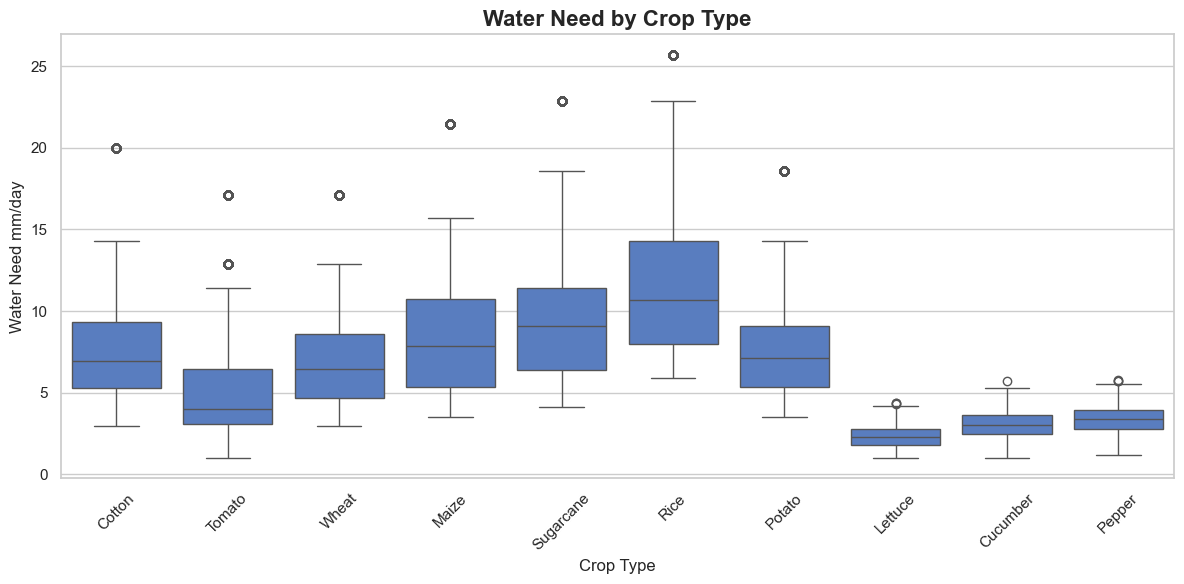

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='CropType', y='WaterNeedmmday')
plt.title('Water Need by Crop Type', fontsize=16, fontweight='bold')
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Water Need mm/day', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

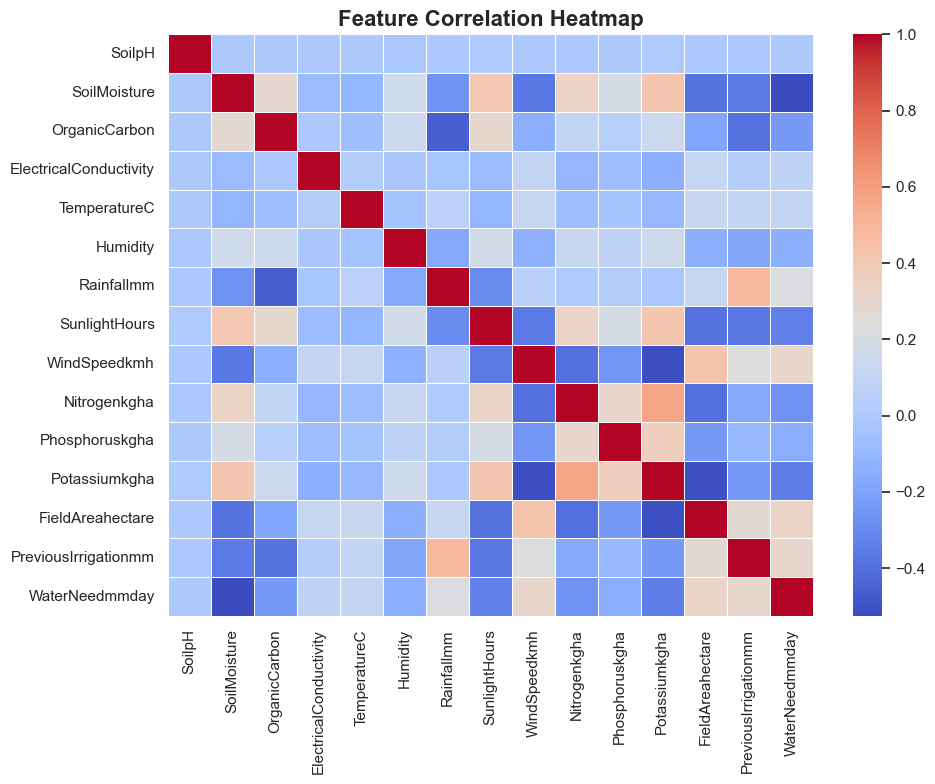

In [16]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Matplotlib Scatter Diagnostics

These plots use plain Matplotlib so the relationship between important
numerical features and the target is easy to inspect without relying only on
seaborn defaults. The color scale represents the target value, which helps
reveal clusters, non-linear behavior, and suspicious target-proxy patterns.

In [20]:
import plotly.express as px

stage_order = ['Sowing', 'Vegetative', 'Flowering', 'Harvest']
df_sorted = df.sort_values(by='CropGrowthStage', key=lambda x: x.map({k: i for i, k in enumerate(stage_order)}))

fig = px.scatter(
    df_sorted, 
    x='TemperatureC', 
    y='WaterNeedmmday', 
    animation_frame='CropGrowthStage', 
    color='CropType',
    hover_name='CropType',
    title='Dynamic Water Need by Temperature Across Growth Stages',
    range_x=[df['TemperatureC'].min() - 2, df['TemperatureC'].max() + 2],
    range_y=[0, df['WaterNeedmmday'].max() + 2],
    template='plotly_white'
)

fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 1200
fig.show()

In [37]:
X = df.drop(['WaterNeedmmday', 'IrrigationNeedLabel'], axis=1, errors='ignore')
y = df['WaterNeedmmday']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = ['CropType', 'SoilType', 'Season', 'IrrigationType', 'MulchingUsed']
ordinal_features = ['CropGrowthStage']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
ordinal_transformer = OrdinalEncoder(categories=[['Sowing', 'Vegetative', 'Flowering', 'Harvest']])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [38]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import numpy as np

dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train_processed, y_train)
dummy_preds = dummy_regr.predict(X_test_processed)

dummy_mae = mean_absolute_error(y_test, dummy_preds)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_preds))

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train_processed, y_train)
xgb_preds = xgb_model.predict(X_test_processed)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("--- Baseline Model ---")
print(f"MAE:  {dummy_mae:.2f}")
print(f"RMSE: {dummy_rmse:.2f}")

print("\n--- XGBoost Model ---")
print(f"MAE:  {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"R^2:  {xgb_r2:.4f}")

--- Baseline Model ---
MAE:  3.52
RMSE: 4.63

--- XGBoost Model ---
MAE:  0.01
RMSE: 0.02
R^2:  1.0000


In [39]:
# Phase 5: Regularization and Preventing Over-optimization
from sklearn.ensemble import HistGradientBoostingRegressor

# We strictly constrain the model architecture
regularized_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.05,     # Slower, more conservative learning
    max_depth=3,            # Shallow trees (reduced from 6)
    min_samples_leaf=30,    # Force generalization by requiring more samples per leaf
    l2_regularization=2.0,  # Penalize complex, heavy-weighted trees
    random_state=42
)

regularized_model.fit(X_train_processed, y_train)

# Predict on both Train and Test to check for variance/overfitting
train_preds = regularized_model.predict(X_train_processed)
test_preds = regularized_model.predict(X_test_processed)

print("--- Regularized Model (TRAIN) ---")
print(f"MAE:  {mean_absolute_error(y_train, train_preds):.4f} mm")
print(f"R^2:  {r2_score(y_train, train_preds):.4f}")

print("\n--- Regularized Model (TEST) ---")
print(f"MAE:  {mean_absolute_error(y_test, test_preds):.4f} mm")
print(f"R^2:  {r2_score(y_test, test_preds):.4f}")

--- Regularized Model (TRAIN) ---
MAE:  0.3210 mm
R^2:  0.9896

--- Regularized Model (TEST) ---
MAE:  0.3208 mm
R^2:  0.9898


Calculating feature importance (this might take a few seconds)...


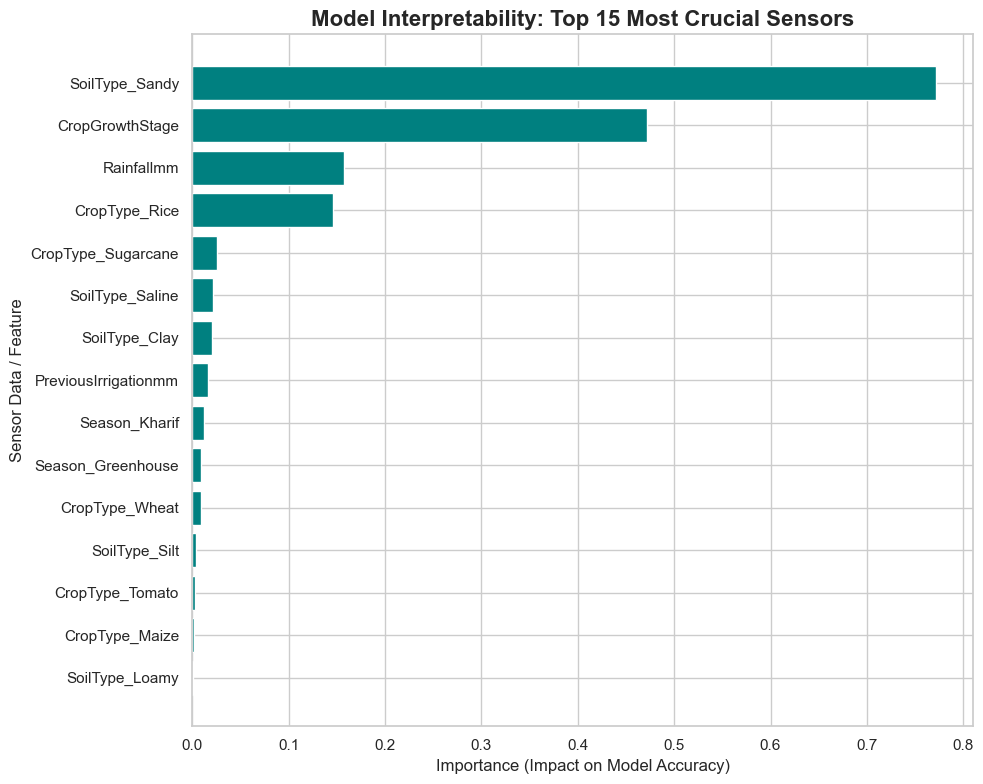

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance

# Extract feature names from our pipeline so the labels are readable
num_cols = numeric_features
cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
ord_cols = ordinal_features

all_feature_names = np.concatenate([num_cols, cat_cols, ord_cols])

# Calculate Permutation Importance on the Test Set
print("Calculating feature importance (this might take a few seconds)...")
result = permutation_importance(
    regularized_model, X_test_processed, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)

# Plot the Top 15 drivers of water need
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][-15:], importance_df['Importance'][-15:], color='teal')
plt.title('Model Interpretability: Top 15 Most Crucial Sensors', fontsize=16, fontweight='bold')
plt.xlabel('Importance (Impact on Model Accuracy)', fontsize=12)
plt.ylabel('Sensor Data / Feature', fontsize=12)
plt.tight_layout()
plt.show()

Initiating 5-Fold Cross Validation... (This runs the entire pipeline 5 times)

--- Cross Validation Results ---
MAE across 5 folds: [0.33079245 0.32768447 0.32976337 0.33239988 0.34623295]
Mean MAE: 0.3334 mm
Standard Deviation: ±0.0066 mm


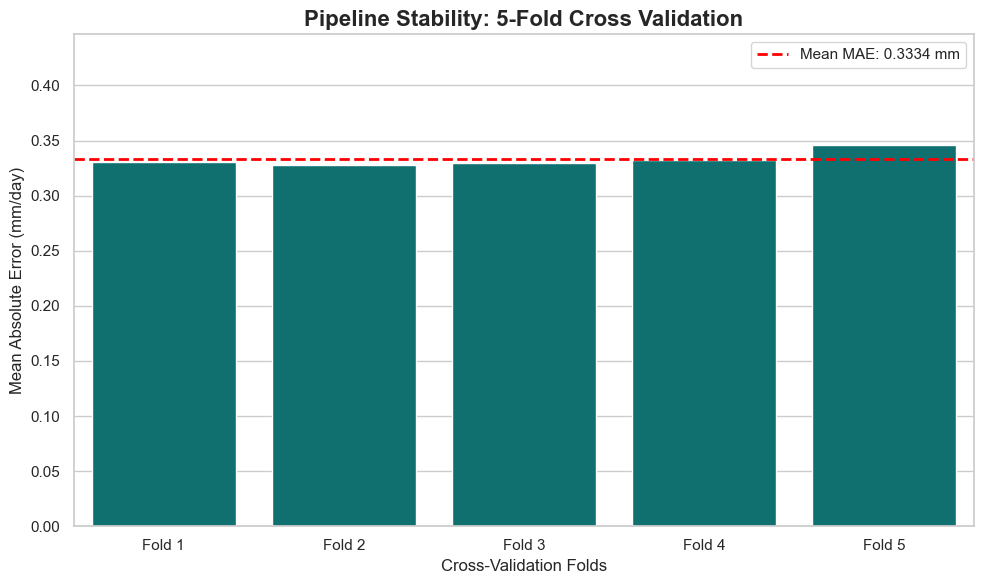

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score

print("Initiating 5-Fold Cross Validation... (This runs the entire pipeline 5 times)")

# 1. Define the K-Fold Strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Run the Cross Validation 
# We use 'neg_mean_absolute_error' because scikit-learn optimization always tries to maximize the score
cv_scores = cross_val_score(
    production_pipeline, 
    X, 
    y, 
    cv=kf, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1 # Uses all CPU cores to run folds in parallel
)

# Convert negative MAE back to positive numbers
cv_mae_scores = -cv_scores

print(f"\n--- Cross Validation Results ---")
print(f"MAE across 5 folds: {cv_mae_scores}")
print(f"Mean MAE: {cv_mae_scores.mean():.4f} mm")
print(f"Standard Deviation: ±{cv_mae_scores.std():.4f} mm")

# 3. Plot the Stability
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="muted")
sns.barplot(x=[f"Fold {i+1}" for i in range(len(cv_mae_scores))], y=cv_mae_scores, color="teal")

# Add the average line
plt.axhline(cv_mae_scores.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean MAE: {cv_mae_scores.mean():.4f} mm')

plt.title('Pipeline Stability: 5-Fold Cross Validation', fontsize=16, fontweight='bold')
plt.ylabel('Mean Absolute Error (mm/day)', fontsize=12)
plt.xlabel('Cross-Validation Folds', fontsize=12)
# Set Y-axis slightly higher than the max to show scale clearly
plt.ylim(0, max(cv_mae_scores) + 0.1) 
plt.legend()
plt.tight_layout()
plt.show()

Running Cross-Validation with Train and Test tracking...


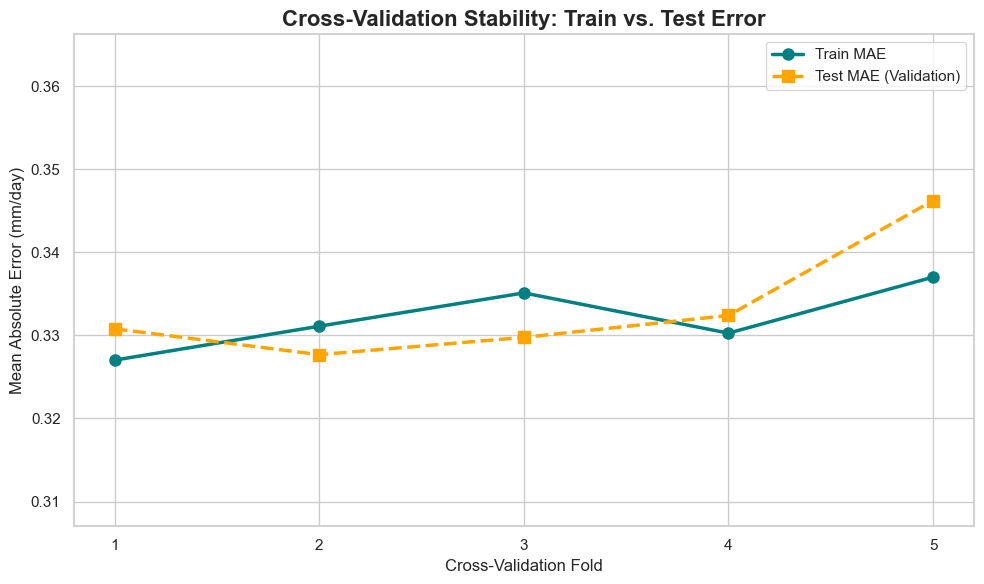

In [42]:


print("Running Cross-Validation with Train and Test tracking...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# We use cross_validate (not cross_val_score) to return both Train and Test scores
cv_results = cross_validate(
    production_pipeline, 
    X, 
    y, 
    cv=kf, 
    scoring='neg_mean_absolute_error', 
    return_train_score=True,  # <--- This extracts the training performance per fold
    n_jobs=-1
)

# Convert negative MAE to positive
train_mae = -cv_results['train_score']
test_mae = -cv_results['test_score']

# Plotting the Train vs Test Curve per Fold
folds = np.arange(1, 6)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="muted")

plt.plot(folds, train_mae, marker='o', label='Train MAE', color='teal', linewidth=2.5, markersize=8)
plt.plot(folds, test_mae, marker='s', label='Test MAE (Validation)', color='orange', linewidth=2.5, linestyle='--', markersize=8)

plt.title('Cross-Validation Stability: Train vs. Test Error', fontsize=16, fontweight='bold')
plt.xlabel('Cross-Validation Fold', fontsize=12)
plt.ylabel('Mean Absolute Error (mm/day)', fontsize=12)
plt.xticks(folds)

# Dynamic y-axis scaling to make the tight gap visible
min_y = min(train_mae.min(), test_mae.min()) - 0.02
max_y = max(train_mae.max(), test_mae.max()) + 0.02
plt.ylim(min_y, max_y)

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
import joblib
from sklearn.pipeline import Pipeline

# 1. Combine the preprocessor and the regularized model into one seamless pipeline
production_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', regularized_model)
])

# 2. Fit the final pipeline on the ENTIRE dataset to maximize learning before deployment
X_processed_final = preprocessor.fit_transform(X)
production_pipeline.fit(X, y)

# 3. Save it to disk
joblib.dump(production_pipeline, 'crop_water_prediction_api_model.pkl')

print("✅ SUCCESS: Pipeline securely packaged as 'crop_water_prediction_api_model.pkl'")
print("Ready for deployment to FastAPI/Flask/Django.")

✅ SUCCESS: Pipeline securely packaged as 'crop_water_prediction_api_model.pkl'
Ready for deployment to FastAPI/Flask/Django.


Running Cross-Validation with Train and Test tracking...


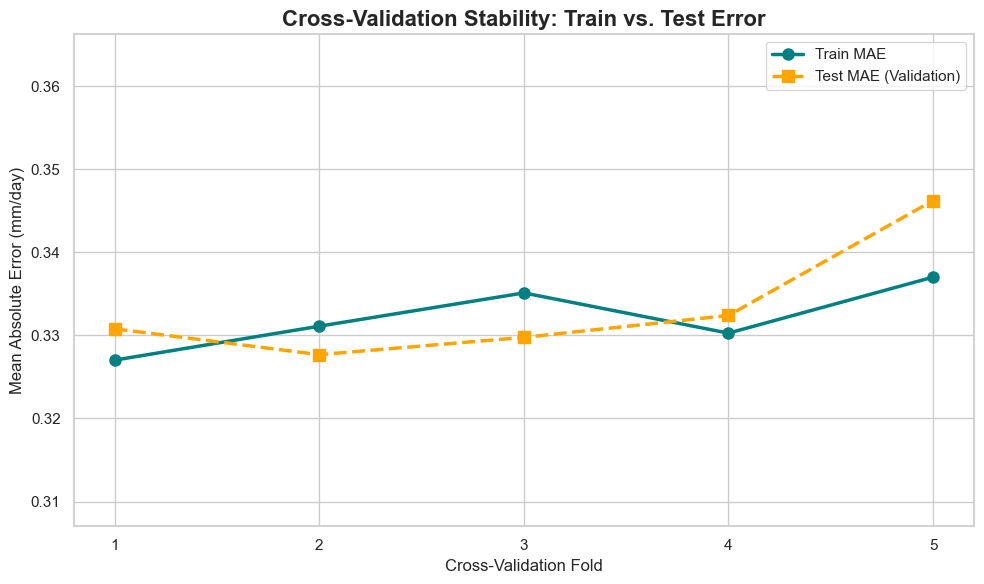

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, KFold

print("Running Cross-Validation with Train and Test tracking...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# We use cross_validate (not cross_val_score) to return both Train and Test scores
cv_results = cross_validate(
    production_pipeline, 
    X, 
    y, 
    cv=kf, 
    scoring='neg_mean_absolute_error', 
    return_train_score=True,  # <--- This extracts the training performance per fold
    n_jobs=-1
)

# Convert negative MAE to positive
train_mae = -cv_results['train_score']
test_mae = -cv_results['test_score']

# Plotting the Train vs Test Curve per Fold
folds = np.arange(1, 6)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="muted")

plt.plot(folds, train_mae, marker='o', label='Train MAE', color='teal', linewidth=2.5, markersize=8)
plt.plot(folds, test_mae, marker='s', label='Test MAE (Validation)', color='orange', linewidth=2.5, linestyle='--', markersize=8)

plt.title('Cross-Validation Stability: Train vs. Test Error', fontsize=16, fontweight='bold')
plt.xlabel('Cross-Validation Fold', fontsize=12)
plt.ylabel('Mean Absolute Error (mm/day)', fontsize=12)
plt.xticks(folds)

# Dynamic y-axis scaling to make the tight gap visible
min_y = min(train_mae.min(), test_mae.min()) - 0.02
max_y = max(train_mae.max(), test_mae.max()) + 0.02
plt.ylim(min_y, max_y)

plt.legend()
plt.tight_layout()
plt.show()

In [36]:

# 1. Load the production pipeline from disk
print("Loading model engine...")
model_pipeline = joblib.load('crop_water_prediction_api_model.pkl')

# 2. Create a single mock data point using the CLEANED column names
mock_sensor_data = pd.DataFrame([{
    'CropType': 'Wheat',
    'SoilType': 'Loamy',
    'CropGrowthStage': 'Vegetative',
    'Season': 'Rabi',
    'SoilpH': 6.5,
    'SoilMoisture': 45.0,
    'OrganicCarbon': 1.2,
    'ElectricalConductivity': 2.5,
    'TemperatureC': 25.0,
    'Humidity': 60.0,
    'Rainfallmm': 0.0,
    'SunlightHours': 8.5,
    'WindSpeedkmh': 12.0,
    'Nitrogenkgha': 50.0,
    'Phosphoruskgha': 20.0,
    'Potassiumkgha': 30.0,
    'IrrigationType': 'Drip',
    'MulchingUsed': 'Yes',
    'FieldAreahectare': 5.0,
    'PreviousIrrigationmm': 0.0
}])

# 3. Run Inference (Prediction)
predicted_water = model_pipeline.predict(mock_sensor_data)

print("\n--- Live Inference Test ---")
print(f"Target Crop: {mock_sensor_data['CropType'].iloc[0]} ({mock_sensor_data['CropGrowthStage'].iloc[0]} Stage)")
print(f"Current Temperature: {mock_sensor_data['TemperatureC'].iloc[0]} °C")
print(f"Current Rainfall: {mock_sensor_data['Rainfallmm'].iloc[0]} mm")
print(f"👉 Predicted Daily Water Need: {predicted_water[0]:.2f} mm/day")

Loading model engine...

--- Live Inference Test ---
Target Crop: Wheat (Vegetative Stage)
Current Temperature: 25.0 °C
Current Rainfall: 0.0 mm
👉 Predicted Daily Water Need: 2.47 mm/day


In [32]:
dashboard_path = Path("streamlit_crop_water_dashboard.py")

print("Dashboard script:", dashboard_path.resolve())
print("Run command: streamlit run streamlit_crop_water_dashboard.py")

Dashboard script: D:\Graduation project\model 2\streamlit_crop_water_dashboard.py
Run command: streamlit run streamlit_crop_water_dashboard.py
